In [4]:
import pandas as pd

df = pd.read_csv("Bookings-100000-Rows - July.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns:", df.columns.tolist())

# Detect important columns
date_col = next((c for c in df.columns if 'date' in c or 'time' in c), None)
fare_col = next((c for c in df.columns if 'fare' in c or 'amount' in c or 'price' in c), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['hour'] = df[date_col].dt.hour

if fare_col:
    df[fare_col] = pd.to_numeric(df[fare_col], errors='coerce')
    df = df[df[fare_col] > 0]

print("✅ Data cleaned successfully")

Columns: ['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'v_tat', 'c_tat', 'canceled_rides_by_customer', 'canceled_rides_by_driver', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'payment_method', 'ride_distance', 'driver_ratings', 'customer_rating', 'vehicle_images']
✅ Data cleaned successfully


In [5]:
print(df.head())
print(df.isnull().sum())
print(df.describe(include='all'))

                 date      time     booking_id        booking_status  \
0 2024-07-26 14:00:00  14:00:00  CNR7153255142    Canceled by Driver   
1 2024-07-25 22:20:00  22:20:00  CNR2940424040               Success   
2 2024-07-30 19:59:00  19:59:00  CNR2982357879               Success   
3 2024-07-22 03:15:00   3:15:00  CNR2395710036  Canceled by Customer   
4 2024-07-02 09:02:00   9:02:00  CNR1797421769               Success   

  customer_id vehicle_type pickup_location drop_location  v_tat  c_tat  ...  \
0   CID713523  Prime Sedan     Tumkur Road      RT Nagar    NaN    NaN  ...   
1   CID225428         Bike     Magadi Road       Varthur  203.0   30.0  ...   
2   CID270156    Prime SUV   Sahakar Nagar       Varthur  238.0  130.0  ...   
3   CID581320        eBike      HSR Layout   Vijayanagar    NaN    NaN  ...   
4   CID939555         Mini     Rajajinagar   Chamarajpet  252.0   80.0  ...   

       canceled_rides_by_driver incomplete_rides incomplete_rides_reason  \
0  Personal & Ca

In [6]:
# Identify commonly used columns dynamically
status_col = next((c for c in df.columns if 'status' in c), None)
payment_col = next((c for c in df.columns if 'payment' in c), None)
city_col = next((c for c in df.columns if 'city' in c or 'location' in c), None)

# Time features (you already created 'hour')
if date_col:
    df['day'] = df[date_col].dt.day_name()
    df['month'] = df[date_col].dt.month
    df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday']).astype(int)

# Peak labeling
df['peak_flag'] = df['hour'].apply(
    lambda x: 'Peak' if pd.notna(x) and (7 <= x <= 10 or 17 <= x <= 21) else 'Non-Peak'
)

# Revenue proxy (standardize name)
if fare_col:
    df['revenue'] = df[fare_col]

In [7]:
total_bookings = len(df)
total_revenue = df['revenue'].sum() if 'revenue' in df else 0

cancel_rate = None
if status_col:
    cancel_rate = (df[status_col].str.lower().eq('cancelled').mean()) * 100

avg_ride_value = df['revenue'].mean() if 'revenue' in df else 0

print({
    "total_bookings": total_bookings,
    "total_revenue": round(total_revenue, 2),
    "avg_ride_value": round(avg_ride_value, 2),
    "cancel_rate_%": round(cancel_rate, 2) if cancel_rate is not None else None
})

{'total_bookings': 103024, 'total_revenue': 0, 'avg_ride_value': 0, 'cancel_rate_%': np.float64(0.0)}


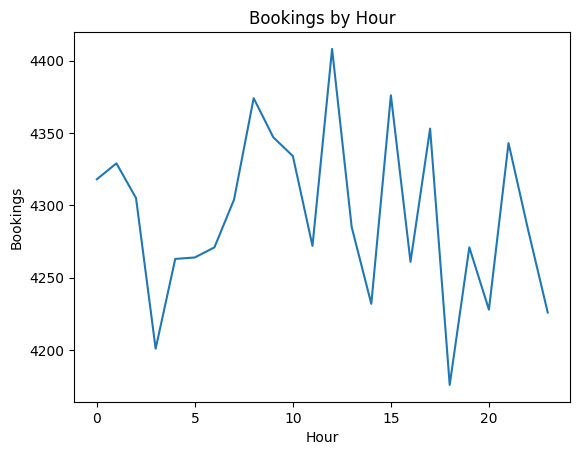

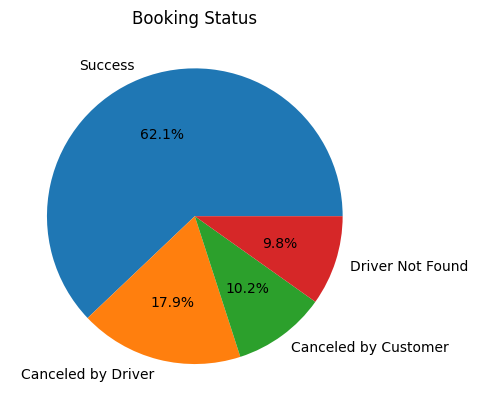

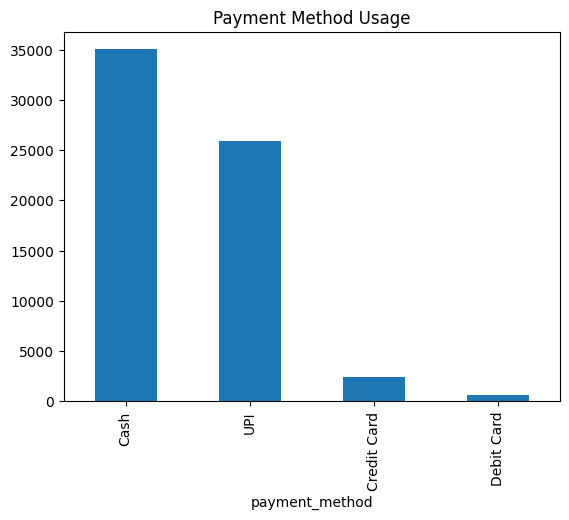

In [8]:
import matplotlib.pyplot as plt

# Bookings by hour
df.groupby('hour').size().plot(title="Bookings by Hour")
plt.xlabel("Hour"); plt.ylabel("Bookings")
plt.show()

# Revenue by day
if 'revenue' in df:
    df.groupby('day')['revenue'].sum().plot(kind='bar', title="Revenue by Day")
    plt.show()

# Status distribution
if status_col:
    df[status_col].value_counts().plot(kind='pie', autopct='%1.1f%%', title="Booking Status")
    plt.ylabel('')
    plt.show()

# Payment method
if payment_col:
    df[payment_col].value_counts().plot(kind='bar', title="Payment Method Usage")
    plt.show()

In [12]:
if city_col and 'revenue' in df.columns:
    print(df.groupby(city_col)['revenue'].sum().sort_values(ascending=False).head())

pickup_location
RT Nagar        1225150
Banashankari    1220409
Nagarbhavi      1211057
Yeshwanthpur    1188522
Frazer Town     1175684
Name: revenue, dtype: int64


In [13]:
print(df.columns.tolist())
print(df.head())
print("Revenue column exists:", 'revenue' in df.columns)

['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'v_tat', 'c_tat', 'canceled_rides_by_customer', 'canceled_rides_by_driver', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'payment_method', 'ride_distance', 'driver_ratings', 'customer_rating', 'vehicle_images', 'hour', 'day', 'month', 'is_weekend', 'peak_flag', 'revenue']
                 date      time     booking_id        booking_status  \
0 2024-07-26 14:00:00  14:00:00  CNR7153255142    Canceled by Driver   
1 2024-07-25 22:20:00  22:20:00  CNR2940424040               Success   
2 2024-07-30 19:59:00  19:59:00  CNR2982357879               Success   
3 2024-07-22 03:15:00   3:15:00  CNR2395710036  Canceled by Customer   
4 2024-07-02 09:02:00   9:02:00  CNR1797421769               Success   

  customer_id vehicle_type pickup_location drop_location  v_tat  c_tat  ...  \
0   CID713523  Prime Sedan     Tumkur Road      RT Nagar    NaN    NaN  ...   
1

In [14]:
total_bookings = len(df)
total_revenue = df['revenue'].sum()
avg_ride = df['revenue'].mean()

print("Total Bookings:", total_bookings)
print("Total Revenue:", total_revenue)
print("Average Ride Value:", avg_ride)

Total Bookings: 103024
Total Revenue: 56534614
Average Ride Value: 548.7518830563752


In [20]:
df.groupby('peak_flag')['revenue'].sum()

peak_flag
Non-Peak    35412918
Peak        21121696
Name: revenue, dtype: int64

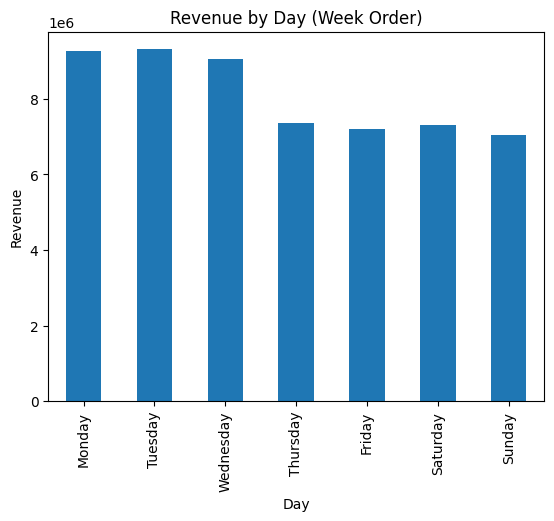

In [24]:
def plot_revenue_by_day(df):
    if 'revenue' in df.columns:
        day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
        
        df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

        result = (
            df.groupby('day', observed=False)['revenue']
            .sum()
            .reindex(day_order)
        )

        plt.figure()
        result.plot(kind='bar', title="Revenue by Day (Week Order)")
        plt.xlabel("Day")
        plt.ylabel("Revenue")
        plt.show()

plot_revenue_by_day(df)